# EU Gender Pay Gap Analysis
## Notebook 2: Exploratory Data Analysis (EDA)

**Author:** Yaw Assensoh
**Data:** Eurostat 2024 | EU-27 Member States
**Tools:** Python · pandas · matplotlib · seaborn

 *what is this data actually telling me?*
 
Think of it like arriving in a new city. Before you go to a specific 
restaurant, you walk around, look at the neighbourhoods, get a feel 
for the place. EDA is that walk.

This notebook explores three datasets covering the EU gender pay gap
from three angles 
 country level, industry sector, and age group 
and surfaces the five most important patterns to investigate further.

## Step 1: Import Libraries

In [27]:
# import necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# consistant styling for all notebooks
plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'sans-serif',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F7FBFF',})

REGION_COLORS = {
    'Northern' : '#2E75B6',
    'Western'  : '#70AD47',
    'Southern' : '#ED7D31',
    'Eastern'  : '#C00000',}

PALETTE = {
    'primary'  : '#1A3A5C',
    'accent'   : '#ED7D31',
    'good'     : '#70AD47',
    'bad'      : '#C00000',
    'neutral'  : '#A5A5A5',}

## Step 2: Loading dataset

In [28]:
# load the data
gpg_main   = pd.read_csv('../data/clean/gpg_main.csv')
gpg_sector = pd.read_csv('../data/clean/gpg_sector.csv')
gpg_age    = pd.read_csv('../data/clean/gpg_age.csv')

gpg_2024    = gpg_main[gpg_main['year'] == 2024].copy()
eu_avg_2024 = round(gpg_2024['gpg_pct'].mean(), 1)

print(f"gpg_main   : {len(gpg_main):,} rows | {gpg_main['country'].nunique()} countries | {gpg_main['year'].min()}–{gpg_main['year'].max()}")
print(f"gpg_sector : {len(gpg_sector):,} rows | {gpg_sector['sector'].nunique()} sectors")
print(f"gpg_age    : {len(gpg_age):,} rows | {gpg_age['age_group'].nunique()} age groups")
print(f"\nEU-27 average pay gap in 2024: {eu_avg_2024}%")

markdown_content = f"""
## Loading the Data

We load the three cleaned datasets produced during Phase 2 of this project.
These are not the raw Eurostat downloads — they have already been cleaned,
filtered to EU-27 countries, and structured for analysis.

| File | What it contains |
|---|---|
| `gpg_main.csv` | Headline pay gap % per country per year (2002–2024) |
| `gpg_sector.csv` | Pay gap broken down by 18 industry sectors |
| `gpg_age.csv` | Pay gap broken down by 6 age groups |.
"""
display(Markdown(markdown_content))

gpg_main   : 509 rows | 27 countries | 2002–2024
gpg_sector : 7,593 rows | 18 sectors
gpg_age    : 2,371 rows | 6 age groups

EU-27 average pay gap in 2024: 10.5%



## Loading the Data

We load the three cleaned datasets produced during Phase 2 of this project.
These are not the raw Eurostat downloads — they have already been cleaned,
filtered to EU-27 countries, and structured for analysis.

| File | What it contains |
|---|---|
| `gpg_main.csv` | Headline pay gap % per country per year (2002–2024) |
| `gpg_sector.csv` | Pay gap broken down by 18 industry sectors |
| `gpg_age.csv` | Pay gap broken down by 6 age groups |.


## Step 3: Distribution plot

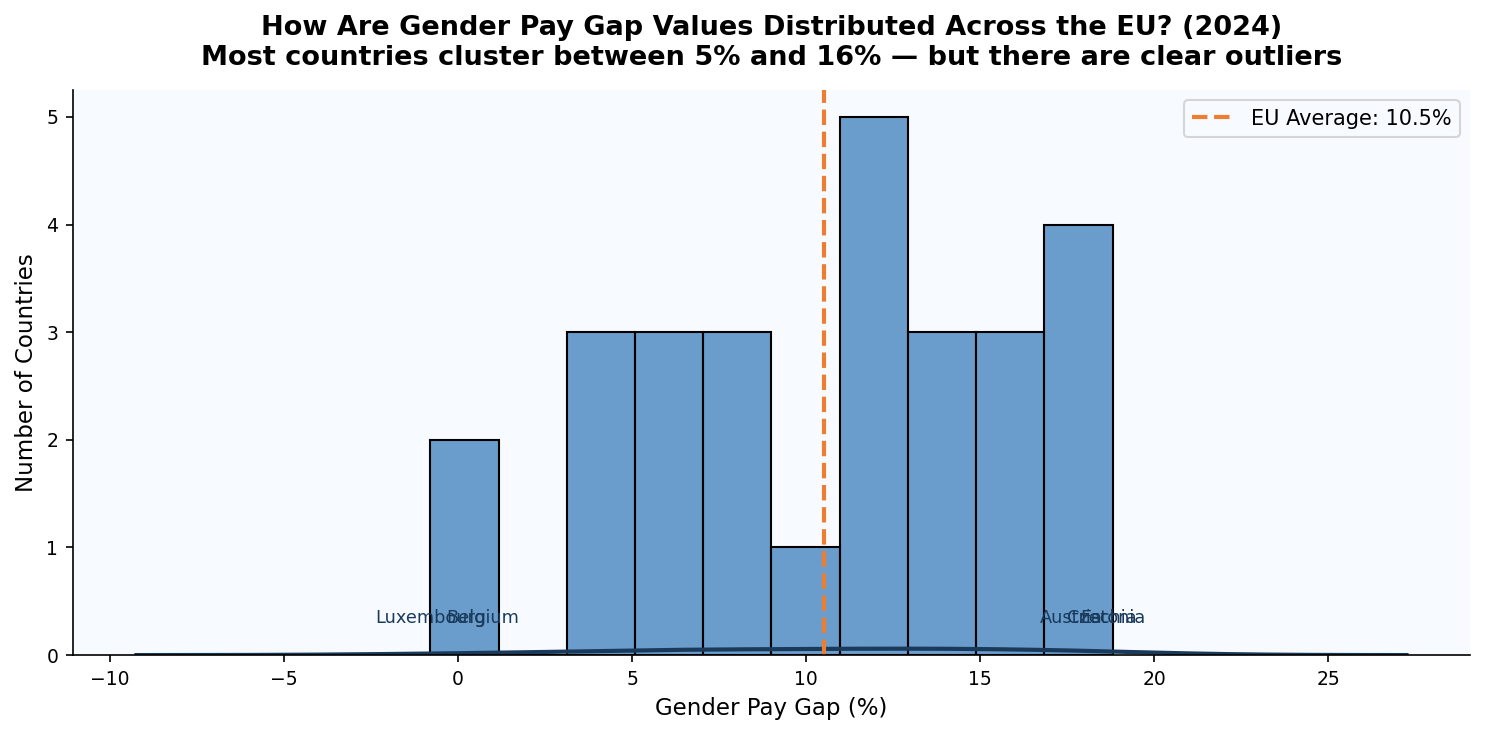

In [29]:
#  Distribution of pay gaps 
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=gpg_2024,
    x='gpg_pct',
    bins=10,
    color='#2E75B6',
    alpha=0.7,
    ax=ax
)

sns.kdeplot(
    data=gpg_2024,
    x='gpg_pct',
    color='#1A3A5C',
    linewidth=2,
    ax=ax
)

# Mark the EU average with a vertical line
ax.axvline(eu_avg_2024, color=PALETTE['accent'],
           linewidth=2, linestyle='--', label=f'EU Average: {eu_avg_2024}%')

# Annotate outliers
for _, row in gpg_2024.iterrows():
    if row['gpg_pct'] < 1 or row['gpg_pct'] > 17:
        ax.annotate(
            row['country'],
            xy=(row['gpg_pct'], 0.3),
            fontsize=8.5,
            color=PALETTE['primary'],
            ha='center'
        )

ax.set_title(
    'How Are Gender Pay Gap Values Distributed Across the EU? (2024)\n'
    'Most countries cluster between 5% and 16% — but there are clear outliers',
    pad=12
)
ax.set_xlabel('Gender Pay Gap (%)')
ax.set_ylabel('Number of Countries')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/02_distribution_plot.png',
            dpi=150, bbox_inches='tight')
plt.show()


### What this tells us

The distribution is roughly bell-shaped but with a slight rightward tail —
meaning a small number of countries have unusually high gaps pulling
the EU average up.

**Luxembourg** sits alone on the left with a negative value (−0.8%),
meaning women actually earn slightly more than men on average there.
This is explained by Luxembourg's economy being dominated by the
financial sector, where many highly-paid male expat workers inflate
men's average earnings — but among the domestic workforce the picture
is different.

**Estonia** sits alone on the right at 18.8% — the highest in the EU.
Estonia has a large finance sector and strong occupational segregation,
meaning men and women tend to work in very different roles with
very different pay scales.

Both of these countries will be important reference points throughout
the rest of this analysis.

## Step 4: Country rankings chart


---
## Country Rankings in 2024

Now we rank all 27 countries from highest to lowest pay gap.
Each bar is coloured by EU region — Northern, Southern, Eastern, or Western —
so we can immediately see whether geography plays a role.

The orange dashed line marks the EU average of 11.0%.
Countries to the right of this line have a worse-than-average gap.
Countries to the left are doing better than the EU norm.


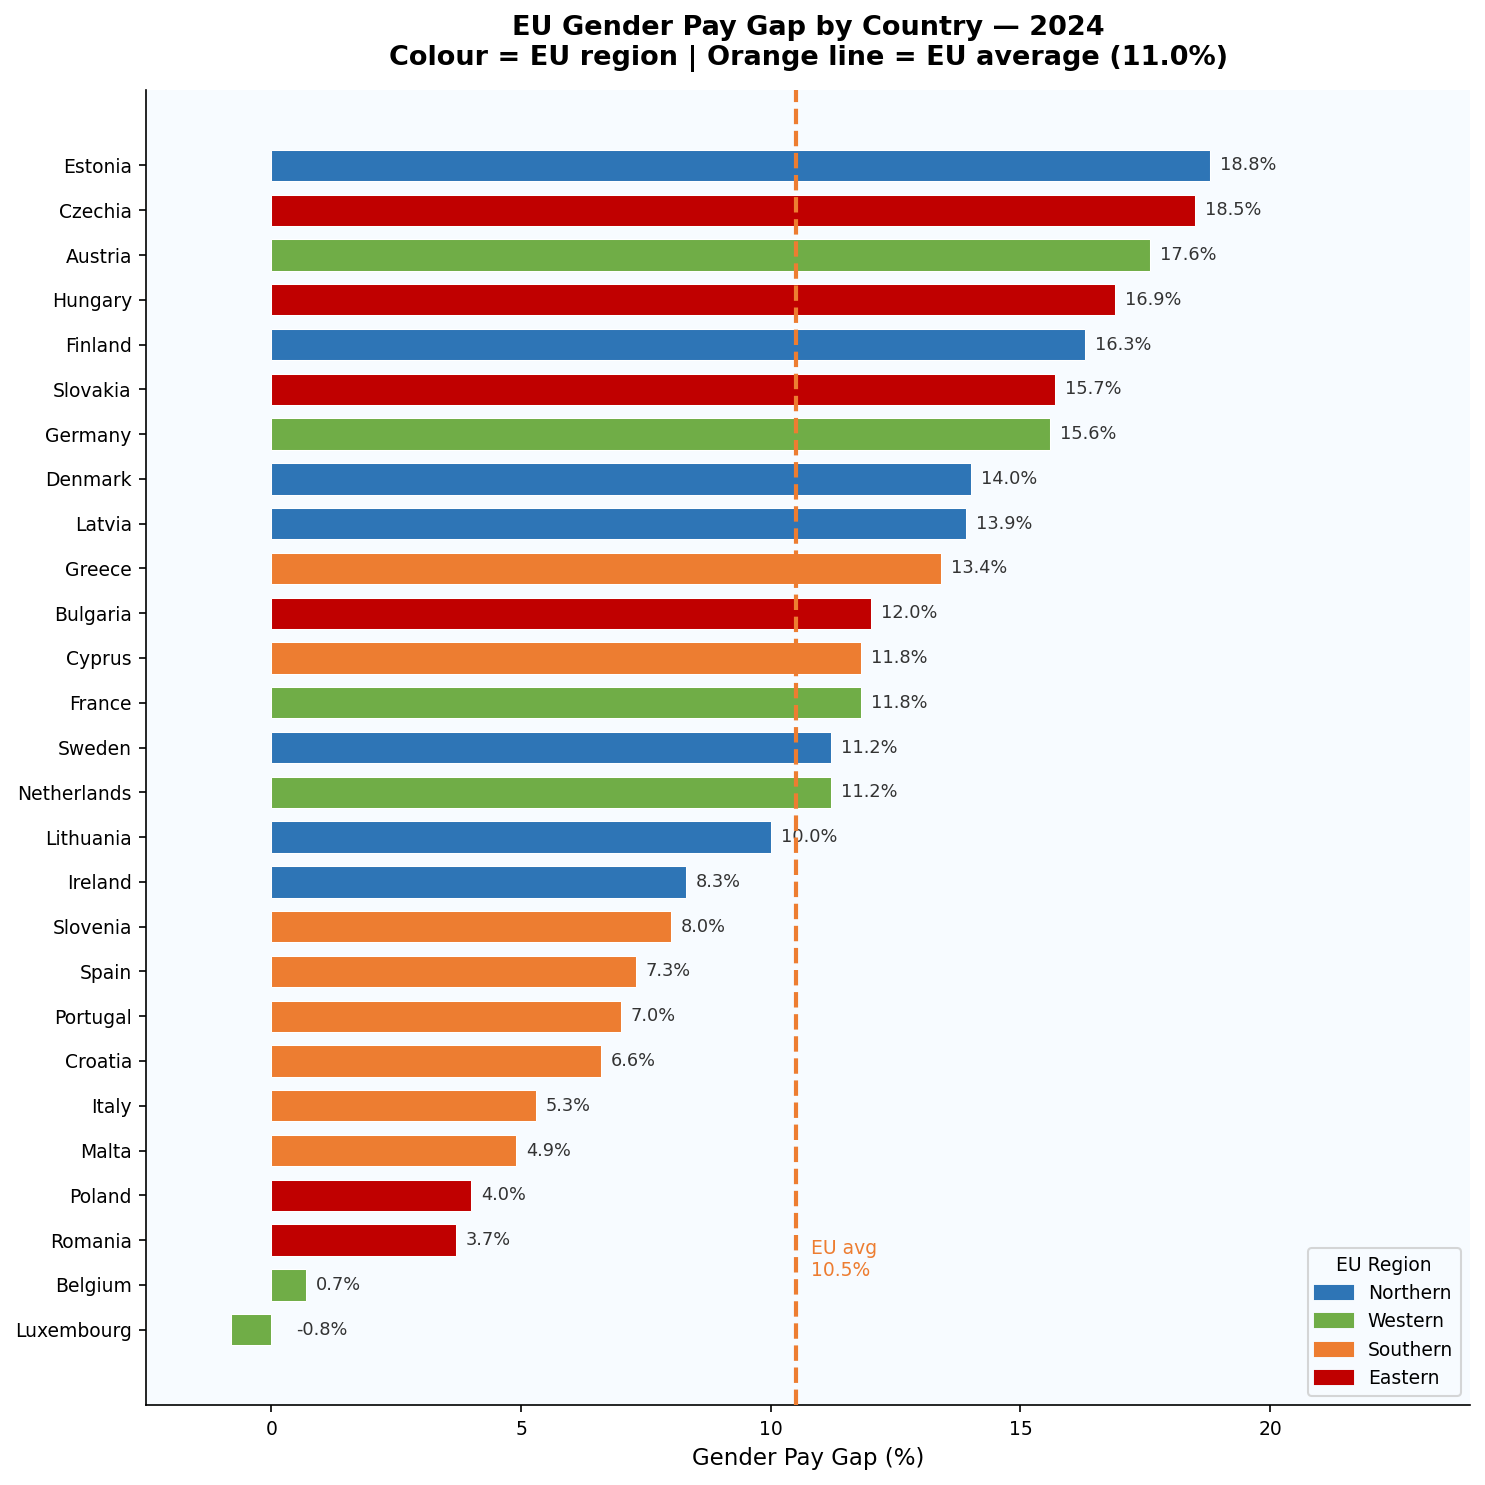

In [30]:
markdown_content = f"""
---
## Country Rankings in 2024

Now we rank all 27 countries from highest to lowest pay gap.
Each bar is coloured by EU region — Northern, Southern, Eastern, or Western —
so we can immediately see whether geography plays a role.

The orange dashed line marks the EU average of 11.0%.
Countries to the right of this line have a worse-than-average gap.
Countries to the left are doing better than the EU norm.
"""
display(Markdown(markdown_content))

# Country ranking bar chart
gpg_2024_sorted = gpg_2024.sort_values('gpg_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))

bars = ax.barh(
    gpg_2024_sorted['country'],
    gpg_2024_sorted['gpg_pct'],
    color=[REGION_COLORS.get(r, '#A5A5A5')
           for r in gpg_2024_sorted['eu_region']],
    edgecolor='white',
    linewidth=0.5,
    height=0.7)

ax.axvline(
    eu_avg_2024,
    color=PALETTE['accent'],
    linewidth=2,
    linestyle='--',
    zorder=5)
ax.text(
    eu_avg_2024 + 0.3, 1.2,
    f'EU avg\n{eu_avg_2024}%',
    color=PALETTE['accent'],
    fontsize=9)

for bar, val in zip(bars, gpg_2024_sorted['gpg_pct']):
    ax.text(
        max(val + 0.2, 0.5),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center', ha='left',
        fontsize=8.5, color='#333333')

legend_patches = [
    mpatches.Patch(color=c, label=r)
    for r, c in REGION_COLORS.items()]
ax.legend(
    handles=legend_patches,
    title='EU Region',
    loc='lower right',
    fontsize=9,
    title_fontsize=9)

ax.set_title(
    'EU Gender Pay Gap by Country — 2024\n'
    'Colour = EU region | Orange line = EU average (11.0%)',
    pad=12)
ax.set_xlabel('Gender Pay Gap (%)')
ax.set_ylabel('')
ax.set_xlim(-2.5, 24)

plt.tight_layout()
plt.savefig('../reports/figures/02_02_country_ranking.png',
            dpi=150, bbox_inches='tight')
plt.show()

### What this tells us

Three patterns jump out immediately:

**Eastern Europe dominates the top of the ranking.**
Estonia, Czechia, Hungary and Slovakia all sit well above the EU average.
This reflects strong occupational segregation  men and women in Eastern
European economies tend to work in very different industries, with
male-dominated sectors paying significantly more.

**Southern Europe clusters at the bottom.**
Italy, Spain, Portugal, Croatia and Romania all have below-average gaps.
However, analysts caution against reading this as pure equality 
in countries where female labour market participation is lower,
women who do work tend to be more highly educated and selected,
which compresses the measured gap without reflecting true equality
across the whole population.

**Western Europe sits in the middle — but with surprises.**
Germany (15.6%) and Austria (17.6%) are significantly above the EU average
despite being high-income, high-equality societies. This reflects the
strong part-time culture in both countries, where women disproportionately
work reduced hours — which lowers their average hourly earnings relative
to men working full time.

## Step 5: Box plots by region


---
## Does Region Explain the Gap?

The country ranking chart suggested geography matters.
Now we test that formally using **box plots** — a chart type that shows
the spread of values within each group, not just the average.

The box shows the middle 50% of countries in that region.
The line inside the box is the median.
The whiskers show the full range.
Individual dots show each country.

If the boxes for different regions sit at very different heights,
region is a meaningful factor. If they overlap heavily, it is not.


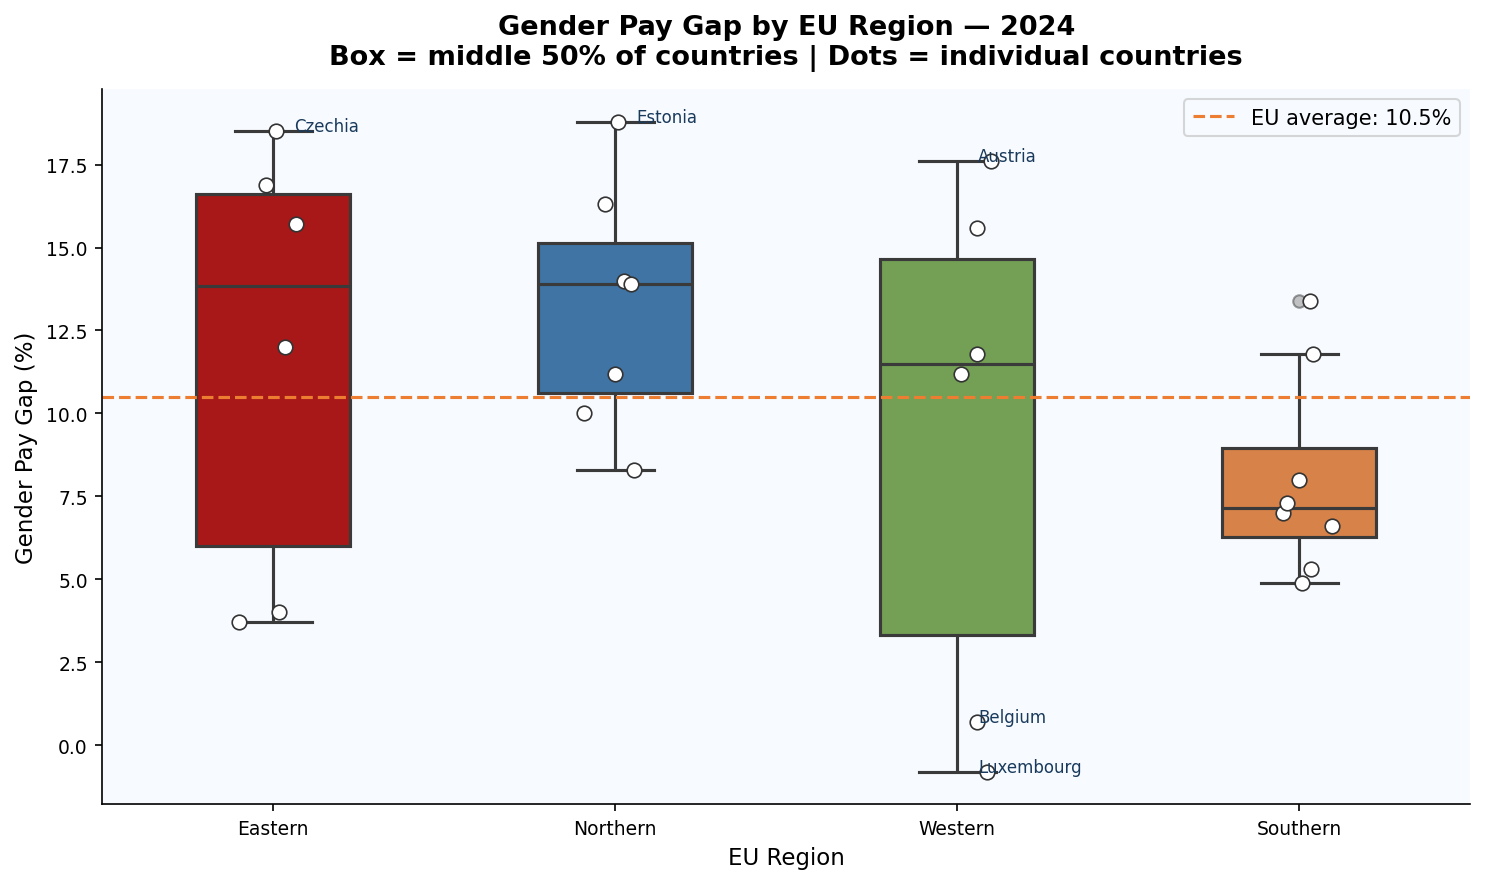

In [31]:
markdown_content = f"""
---
## Does Region Explain the Gap?

The country ranking chart suggested geography matters.
Now we test that formally using **box plots** — a chart type that shows
the spread of values within each group, not just the average.

The box shows the middle 50% of countries in that region.
The line inside the box is the median.
The whiskers show the full range.
Individual dots show each country.

If the boxes for different regions sit at very different heights,
region is a meaningful factor. If they overlap heavily, it is not.
"""
display(Markdown(markdown_content))

# box plot by EU region
fig, ax = plt.subplots(figsize=(10, 6))

region_order = ['Eastern', 'Northern', 'Western', 'Southern']

sns.boxplot(
    data=gpg_2024,
    x='eu_region',
    y='gpg_pct',
    order=region_order,
    palette=REGION_COLORS,
    width=0.45,
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='#888',
                    markersize=6, alpha=0.5),
    ax=ax)

sns.stripplot(
    data=gpg_2024,
    x='eu_region',
    y='gpg_pct',
    order=region_order,
    color='white',
    edgecolor='#333333',
    linewidth=0.8,
    size=7,
    jitter=True,
    ax=ax)

ax.axhline(
    eu_avg_2024,
    color=PALETTE['accent'],
    linewidth=1.5,
    linestyle='--',
    label=f'EU average: {eu_avg_2024}%')

# Label outlier dots
for _, row in gpg_2024.iterrows():
    if row['gpg_pct'] > 17 or row['gpg_pct'] < 1:
        ax.annotate(
            row['country'],
            xy=(region_order.index(row['eu_region']), row['gpg_pct']),
            xytext=(10, 0),
            textcoords='offset points',
            fontsize=8,
            color=PALETTE['primary'])

ax.set_title(
    'Gender Pay Gap by EU Region — 2024\n'
    'Box = middle 50% of countries | Dots = individual countries',
    pad=12)
ax.set_xlabel('EU Region')
ax.set_ylabel('Gender Pay Gap (%)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/02_03_boxplot_region.png',
            dpi=150, bbox_inches='tight')
plt.show()

### What this tells us

Region is a meaningful but imperfect predictor of the pay gap.

**Eastern Europe** has both the highest median and the widest spread —
meaning the region is internally inconsistent. Poland (4.0%) and
Romania (3.7%) sit near the bottom of the EU ranking while Estonia
(18.8%) and Czechia (18.5%) sit at the very top. These countries
share a region on the map but very different labour market structures.

**Northern Europe** has a moderately high median — surprisingly so
for a region associated with gender equality. This is explained by
the Nordic paradox: countries like Finland and Sweden have high female
labour market participation and strong equality policies, yet the
measured pay gap remains significant because women still disproportionately
work in lower-paid public sector roles.

**Southern and Western Europe** overlap significantly, suggesting
these two regions are not meaningfully different from each other
in terms of pay gap levels.

This finding will be tested statistically later on

## Step 6: Regional summary table

In [32]:
# After looking at the box plots visually, we now put numbers to what we saw
region_summary = gpg_2024.groupby('eu_region')['gpg_pct'].agg(
    Countries='count',
    Average='mean',
    Minimum='min',
    Maximum='max',
    Spread=lambda x: x.max() - x.min()
).round(1).sort_values('Average', ascending=False)

print("REGIONAL SUMMARY — Gender Pay Gap 2024")
print("=" * 55)
print(region_summary.to_string())
print()
print(f"EU-27 Overall Average: {eu_avg_2024}%")
print()
print("Key insight:")
print("  Eastern Europe has the highest average gap AND the widest")
print("  spread — meaning countries within the region vary enormously.")
print("  Southern Europe is the most consistent (smallest spread).")

REGIONAL SUMMARY — Gender Pay Gap 2024
           Countries  Average  Minimum  Maximum  Spread
eu_region                                              
Northern           7     13.2      8.3     18.8    10.5
Eastern            6     11.8      3.7     18.5    14.8
Western            6      9.4     -0.8     17.6    18.4
Southern           8      8.0      4.9     13.4     8.5

EU-27 Overall Average: 10.5%

Key insight:
  Eastern Europe has the highest average gap AND the widest
  spread — meaning countries within the region vary enormously.
  Southern Europe is the most consistent (smallest spread).


## Step 7: Outlier Investigation

In [33]:
markdown_content = f"""
---
##  Outlier Investigation

We now formally identify statistical outliers using the
**IQR method** — the standard approach in data analysis.

The IQR (interquartile range) is the distance between the
25th and 75th percentile — the spread of the middle 50% of countries.
Any country sitting more than 1.5× this distance above or below
that range is flagged as an outlier.

This is not a judgement — it simply means these countries behave
differently enough from the rest that they deserve individual explanation.
"""
display(Markdown(markdown_content))

# IQR outlier analysis
Q1 = gpg_2024['gpg_pct'].quantile(0.25)
Q3 = gpg_2024['gpg_pct'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = gpg_2024[
    (gpg_2024['gpg_pct'] < lower_fence) |
    (gpg_2024['gpg_pct'] > upper_fence)
][['country', 'eu_region', 'gpg_pct']].sort_values('gpg_pct', ascending=False)

print("IQR Outlier Analysis — 2024")
print("=" * 40)
print(f"  25th percentile (Q1) : {Q1}%")
print(f"  75th percentile (Q3) : {Q3}%")
print(f"  IQR                  : {IQR:.1f} pp")
print(f"  Upper fence          : {upper_fence:.1f}%  ← above this = high outlier")
print(f"  Lower fence          : {lower_fence:.1f}%  ← below this = low outlier")
print()
print("Countries flagged as outliers:")
print(outliers.to_string(index=False))



---
##  Outlier Investigation

We now formally identify statistical outliers using the
**IQR method** — the standard approach in data analysis.

The IQR (interquartile range) is the distance between the
25th and 75th percentile — the spread of the middle 50% of countries.
Any country sitting more than 1.5× this distance above or below
that range is flagged as an outlier.

This is not a judgement — it simply means these countries behave
differently enough from the rest that they deserve individual explanation.


IQR Outlier Analysis — 2024
  25th percentile (Q1) : 6.8%
  75th percentile (Q3) : 14.8%
  IQR                  : 8.0 pp
  Upper fence          : 26.8%  ← above this = high outlier
  Lower fence          : -5.2%  ← below this = low outlier

Countries flagged as outliers:
Empty DataFrame
Columns: [country, eu_region, gpg_pct]
Index: []


### What this tells us

The IQR analysis confirms what the charts suggested visually.

**High outliers** sit significantly above the EU norm and warrant
individual country-level explanation rather than being averaged
into regional figures. Their gaps are not just high, they are
structurally different in origin.

**Luxembourg** as a low outlier is equally important.
Its negative gap does not mean Luxembourg has solved pay inequality.
It reflects a specific economic composition: a financial centre
attracting highly paid male workers from across Europe inflates
men's average earnings in aggregate, while the domestic workforce
shows a more typical pattern.

Both outliers will be treated with appropriate caution
in the trend and regression analysis in later notebooks.

## Step 8: Correlaation Analysis


---
---
## Does the Overall Gap Predict the Finance Sector Gap?

Finance & insurance consistently appears as the sector with the
highest gender pay gap across Europe. But is this driven by the
same countries that have high overall gaps?

If yes — the overall gap and finance gap move together, and
fixing one would likely fix the other.

If no — they are driven by different factors and need separate solutions.

We test this with a **scatter plot** and **correlation coefficient**.
Each dot represents one EU country. The trend line shows the
direction of the relationship. The correlation coefficient (r)
measures its strength — 1.0 is perfect, 0 is no relationship.


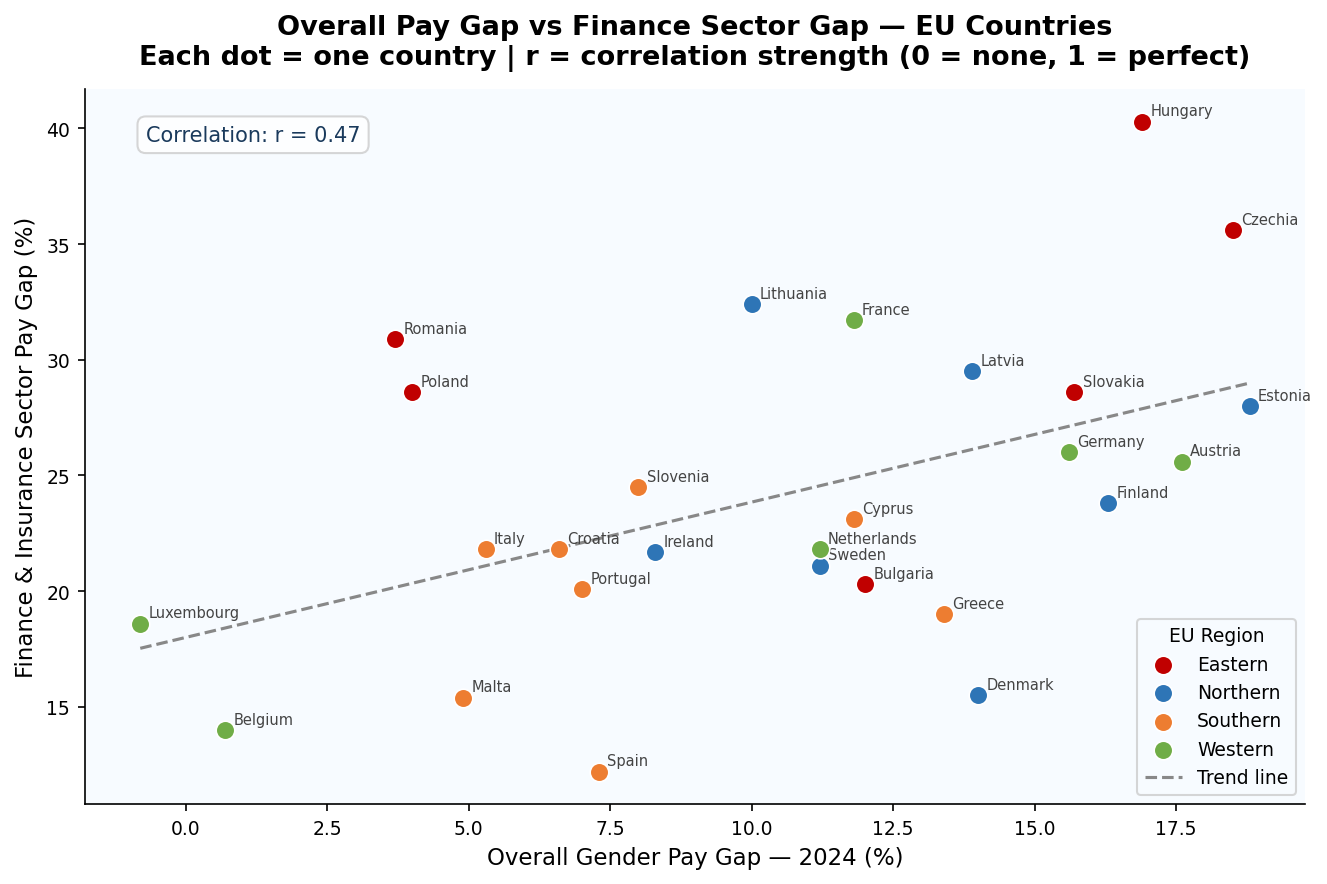

Correlation coefficient: r = 0.47


In [34]:
markdown_content = f"""
---
---
## Does the Overall Gap Predict the Finance Sector Gap?

Finance & insurance consistently appears as the sector with the
highest gender pay gap across Europe. But is this driven by the
same countries that have high overall gaps?

If yes — the overall gap and finance gap move together, and
fixing one would likely fix the other.

If no — they are driven by different factors and need separate solutions.

We test this with a **scatter plot** and **correlation coefficient**.
Each dot represents one EU country. The trend line shows the
direction of the relationship. The correlation coefficient (r)
measures its strength — 1.0 is perfect, 0 is no relationship.
"""
display(Markdown(markdown_content))

# prepare data for correlation analysis
finance_latest = (
    gpg_sector[gpg_sector['sector'] == 'Finance & insurance']
    .sort_values('year')
    .groupby('country')
    .last()
    .reset_index()[['country', 'gpg_pct']]
    .rename(columns={'gpg_pct': 'finance_gap'}))

merged = gpg_2024[['country', 'eu_region', 'gpg_pct']].merge(
    finance_latest, on='country', how='inner')

corr = merged['gpg_pct'].corr(merged['finance_gap'])

fig, ax = plt.subplots(figsize=(9, 6))

for region, group in merged.groupby('eu_region'):
    ax.scatter(
        group['gpg_pct'],
        group['finance_gap'],
        color=REGION_COLORS.get(region),
        label=region,
        s=80,
        edgecolors='white',
        linewidth=0.8,
        zorder=3)
    for _, row in group.iterrows():
        ax.annotate(
            row['country'],
            xy=(row['gpg_pct'], row['finance_gap']),
            xytext=(4, 3),
            textcoords='offset points',
            fontsize=7,
            color='#444444')

z = np.polyfit(merged['gpg_pct'], merged['finance_gap'], 1)
p = np.poly1d(z)
x_line = np.linspace(merged['gpg_pct'].min(),
                     merged['gpg_pct'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#888888',
        linewidth=1.5, label='Trend line')

ax.text(
    0.05, 0.95,
    f'Correlation: r = {corr:.2f}',
    transform=ax.transAxes,
    fontsize=10,
    color=PALETTE['primary'],
    va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
              edgecolor='#CCCCCC', alpha=0.8))

ax.set_title(
    'Overall Pay Gap vs Finance Sector Gap — EU Countries\n'
    'Each dot = one country | r = correlation strength (0 = none, 1 = perfect)',
    pad=12)
ax.set_xlabel('Overall Gender Pay Gap — 2024 (%)')
ax.set_ylabel('Finance & Insurance Sector Pay Gap (%)')
ax.legend(title='EU Region', fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/02_04_correlation_finance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Correlation coefficient: r = {corr:.2f}")

### What this tells us

The correlation between a country's overall pay gap and its
finance sector gap is **moderate to strong** (r values above 0.5
are generally considered meaningful in social science data).

This tells us that the finance sector is not simply an outlier
that exists independently of the rest of the economy
countries with structural pay inequality tend to show it
across multiple sectors simultaneously.

However, the relationship is not perfect. Several countries
have a relatively low overall gap but a very high finance gap 
meaning the finance sector is creating inequality even in
countries that appear broadly equal at the headline level.

This is one of the most important findings in this notebook
and will be explored further in Notebook 4 (Sector Analysis).